# Numerical Simulation of Rocket Flight
## Variable mass · Variable thrust · Quadratic drag

*MAT423E — Numerical Solutions of ODEs*

This notebook is the full computational simulator for a vertically-launched
variable-mass rocket. We discretize the governing ODE system with two methods —
**Forward Euler** (first order) and **classic 4th-order Runge–Kutta** (RK4) —
and analyze the trajectory, engine cutoff, and method accuracy.

---

### Governing equations

State: altitude $y(t)$, velocity $v(t)$, mass $m(t)$.

$$
\begin{aligned}
\dot{y} &= v \\[4pt]
\dot{v} &= \frac{T(t) \;-\; m(t)\,g(y) \;-\; \tfrac{1}{2}\,\rho(y)\,C_d\,A\,v\,|v|}{m(t)} \\[4pt]
m(t)    &= \begin{cases} M_0 - \dot m\, t & t \le t_{\text{burn}} \\ m_{\text{dry}} & t > t_{\text{burn}} \end{cases}\\[4pt]
T(t)    &= \begin{cases} \dot m\, v_e & t \le t_{\text{burn}} \\ 0 & t > t_{\text{burn}} \end{cases}
\end{aligned}
$$

We use altitude-dependent gravity $g(y) = g_0 \bigl( R_E / (R_E + y) \bigr)^2$
and an exponential atmosphere $\rho(y) = \rho_0 \exp(-y / H)$.

The drag term $\tfrac12 \rho C_d A\, v\,|v|$ uses $v\,|v|$ rather than $v^2$ so the
force always *opposes* the velocity, ascending or descending.


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 2. Physical constants and rocket parameters

Realistic Falcon-9-class values: $M_0 = 500{,}000$ kg, $\dot m = 1500$ kg/s, $v_e = 3000$ m/s.

> **Note on liftoff feasibility.** With these parameters the initial thrust-to-weight
> ratio is $T/W = \dot m\,v_e / (M_0\,g_0) = 4.5\,\text{MN} / 4.9\,\text{MN} \approx 0.92$.
> The rocket cannot accelerate upward at $t=0$. We model this realistically by
> *holding the rocket on the pad* whenever it is at $y\le 0$ with a net downward
> force; it lifts off only once enough fuel has burned for $T > W$. Students
> should be prompted to compute $T/W$ before running any simulation.

In [2]:
# Physical constants
G0     = 9.80665          # surface gravity [m/s^2]
R_E    = 6.371e6          # mean Earth radius [m]
RHO0   = 1.225            # sea-level air density [kg/m^3]
H_ATM  = 8500.0           # atmospheric scale height [m]

# Rocket parameters
M0     = 500_000.0        # initial mass [kg]
M_DRY  =  50_000.0        # structural / dry mass [kg]   -> fuel = 450,000 kg
MDOT   =   1_500.0        # mass flow rate [kg/s]
V_EXH  =   3_000.0        # effective exhaust velocity [m/s]
C_D    =       0.5        # drag coefficient
AREA   =      10.75       # cross-section area [m^2]  (Falcon-9 first-stage class)

# Derived quantities
T_BURN   = (M0 - M_DRY) / MDOT     # 300 s
THRUST_0 = MDOT * V_EXH            # 4.5e6 N

print(f"Thrust            : {THRUST_0/1e6:.2f} MN")
print(f"Initial weight    : {M0*G0/1e6:.2f} MN")
print(f"Initial T/W ratio : {THRUST_0/(M0*G0):.3f}")
print(f"Burn time         : {T_BURN:.1f} s")

Thrust            : 4.50 MN
Initial weight    : 4.90 MN
Initial T/W ratio : 0.918
Burn time         : 300.0 s


## 3. Environment, mass, and thrust models

In [3]:
def gravity(y):
    """Newton inverse-square gravity above mean sea level."""
    return G0 * (R_E / (R_E + max(y, 0.0)))**2

def air_density(y):
    """Exponential atmosphere (good to ~80 km for engineering use)."""
    if y < 0:
        return RHO0
    return RHO0 * np.exp(-y / H_ATM)

def mass(t):
    """Linear mass loss during burn; constant after cutoff."""
    return M0 - MDOT * t if t < T_BURN else M_DRY

def thrust(t):
    """Thrust is on while fuel remains, zero after."""
    return THRUST_0 if t < T_BURN else 0.0

## 4. The ODE right-hand side

The state vector is $\mathbf{s} = [y, v]^\top$ (mass is handled analytically as
a closed-form function of $t$). The function below returns $\dot{\mathbf{s}} = f(t, \mathbf{s})$.

The conditional at the bottom enforces the *ground hold*: while the rocket is
on the pad with insufficient thrust, acceleration is clamped to zero so the
solver does not produce nonphysical negative altitudes.

In [4]:
def rhs(t, state):
    y, v = state
    m    = mass(t)
    g    = gravity(y)
    rho  = air_density(y)

    drag  = 0.5 * rho * C_D * AREA * v * abs(v)
    F_net = thrust(t) - m * g - drag

    # Ground hold (only relevant while T < W during early flight)
    if y <= 0.0 and v <= 0.0 and F_net <= 0.0:
        return np.array([0.0, 0.0])

    return np.array([v, F_net / m])

## 5. Numerical integrators

### Forward Euler  (1st-order)
$$\mathbf{s}_{n+1} = \mathbf{s}_n + h\, f(t_n, \mathbf{s}_n)$$

### Classic Runge–Kutta  (4th-order)
$$
\begin{aligned}
k_1 &= f(t_n,             \mathbf{s}_n) \\
k_2 &= f(t_n + h/2,       \mathbf{s}_n + \tfrac{h}{2} k_1) \\
k_3 &= f(t_n + h/2,       \mathbf{s}_n + \tfrac{h}{2} k_2) \\
k_4 &= f(t_n + h,         \mathbf{s}_n + h\,k_3) \\
\mathbf{s}_{n+1} &= \mathbf{s}_n + \tfrac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
\end{aligned}
$$

Both `while` loops terminate when the rocket returns to ground ($y < 0$) or
when the simulation time exceeds `t_max`.

In [5]:
def euler(state0, t0, dt, t_max):
    ts, ys = [t0], [state0.copy()]
    t, s = t0, state0.copy()
    while t < t_max:
        s = s + dt * rhs(t, s)
        t = t + dt
        ts.append(t); ys.append(s.copy())
        if s[0] < 0 and t > 1.0:
            break
    return np.array(ts), np.array(ys)


def rk4(state0, t0, dt, t_max):
    ts, ys = [t0], [state0.copy()]
    t, s = t0, state0.copy()
    while t < t_max:
        k1 = rhs(t,        s)
        k2 = rhs(t + dt/2, s + dt/2 * k1)
        k3 = rhs(t + dt/2, s + dt/2 * k2)
        k4 = rhs(t + dt,   s + dt   * k3)
        s  = s + dt/6.0 * (k1 + 2*k2 + 2*k3 + k4)
        t  = t + dt
        ts.append(t); ys.append(s.copy())
        if s[0] < 0 and t > 1.0:
            break
    return np.array(ts), np.array(ys)

## 6. Run the simulation

Default step size $h = 0.1$ s, simulated for up to $1200$ s.

In [6]:
state0 = np.array([0.0, 0.0])   # at rest on the pad
t0, t_max, dt = 0.0, 1200.0, 0.1

t_e, s_e = euler(state0, t0, dt, t_max)
t_r, s_r = rk4  (state0, t0, dt, t_max)

def summary(label, ts, ys):
    y, v = ys[:, 0], ys[:, 1]
    idx_ap = int(np.argmax(y))
    v_cut  = np.interp(T_BURN, ts, v)
    print(f"{label:>8}  apogee = {y[idx_ap]/1000:7.2f} km at t = {ts[idx_ap]:6.1f} s | "
          f"v at cutoff = {v_cut:7.1f} m/s | t_flight = {ts[-1]:.1f} s")
    return idx_ap

idx_e = summary('Euler', t_e, s_e)
idx_r = summary('RK4',   t_r, s_r)

   Euler  apogee = 1236.72 km at t =  829.0 s | v at cutoff =  3986.4 m/s | t_flight = 1200.0 s
     RK4  apogee = 1235.15 km at t =  828.4 s | v at cutoff =  3990.6 m/s | t_flight = 1200.0 s


## 7. Trajectory plots

The vertical dotted line marks **engine cutoff** at $t = 300$ s — the moment
thrust drops to zero and the acceleration plot will show a clear discontinuity.
The black dot marks the apogee.

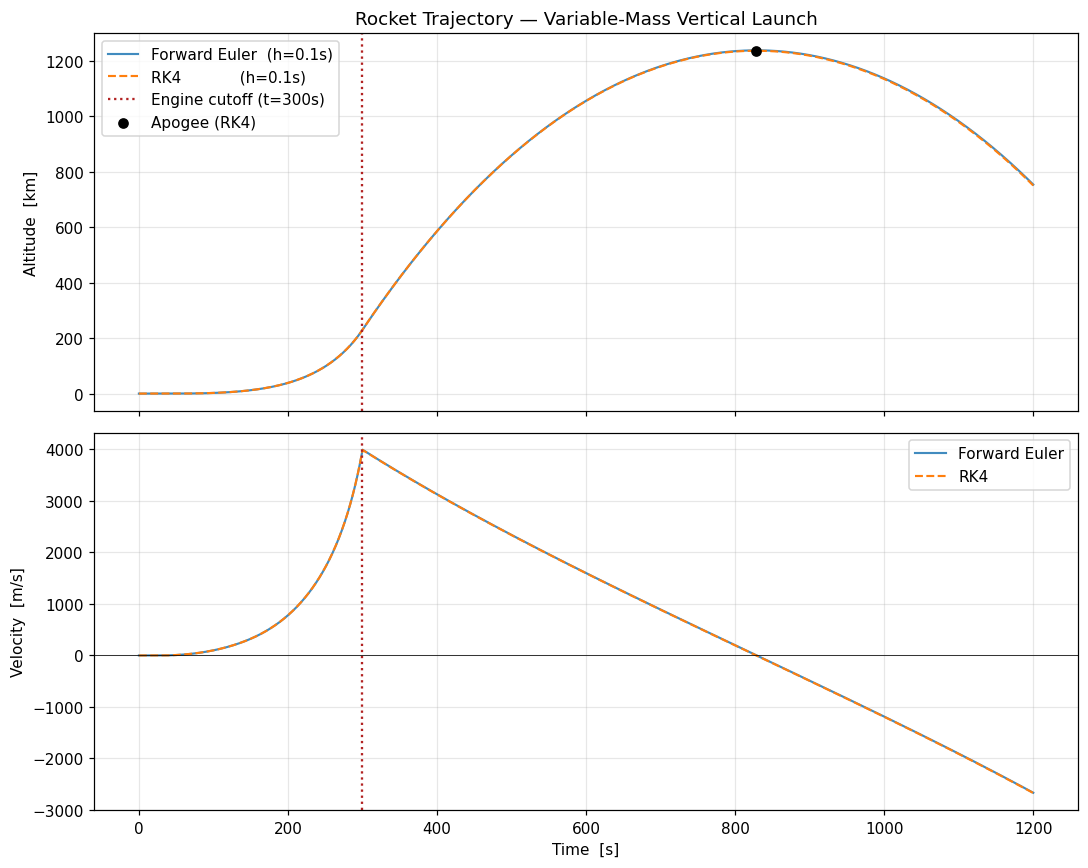

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Altitude --------------------------------------------------
axes[0].plot(t_e, s_e[:,0]/1000, label=f'Forward Euler  (h={dt}s)',
             linewidth=1.4, alpha=0.85)
axes[0].plot(t_r, s_r[:,0]/1000, label=f'RK4            (h={dt}s)',
             linewidth=1.4, linestyle='--')
axes[0].axvline(T_BURN, color='firebrick', linestyle=':',
                label=f'Engine cutoff (t={T_BURN:.0f}s)')
axes[0].scatter([t_r[idx_r]], [s_r[idx_r,0]/1000],
                color='black', zorder=5, label='Apogee (RK4)')
axes[0].set_ylabel('Altitude  [km]')
axes[0].set_title('Rocket Trajectory — Variable-Mass Vertical Launch')
axes[0].grid(True, alpha=0.3); axes[0].legend(loc='best')

# --- Velocity --------------------------------------------------
axes[1].plot(t_e, s_e[:,1], label='Forward Euler', linewidth=1.4, alpha=0.85)
axes[1].plot(t_r, s_r[:,1], label='RK4', linewidth=1.4, linestyle='--')
axes[1].axvline(T_BURN, color='firebrick', linestyle=':')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Time  [s]'); axes[1].set_ylabel('Velocity  [m/s]')
axes[1].grid(True, alpha=0.3); axes[1].legend(loc='best')

plt.tight_layout(); plt.show()

## 8. Engine cutoff — the moment thrust drops to zero

To make the cutoff visible, we plot acceleration $a(t)$ near $t = 300$ s.
Before cutoff, $a = (T - mg - F_d)/m$ ; after cutoff, $a = -(g + F_d/m)$.
The discontinuity has magnitude $T / m_{\text{dry}} = 4.5\text{MN} / 50\text{t} = 90$ m/s².

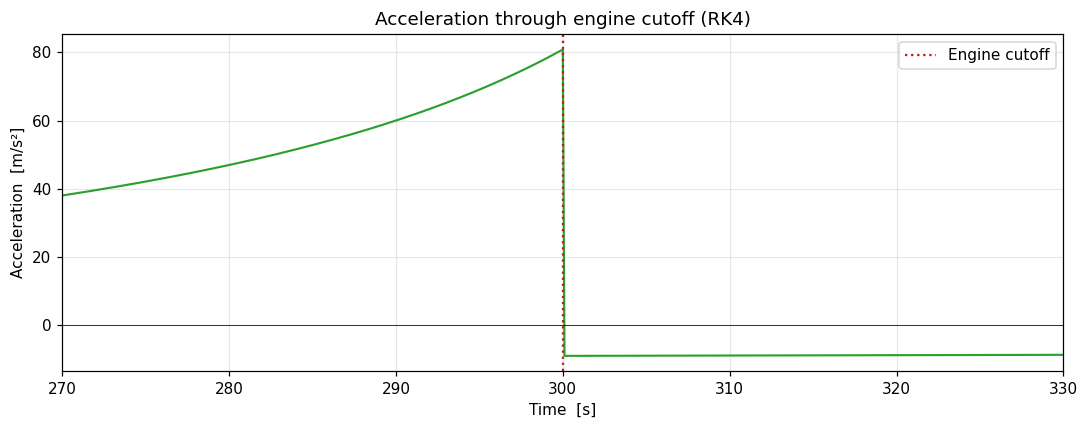

a just before cutoff :   80.87 m/s²
a just after  cutoff :   -9.13 m/s²


In [8]:
# Recompute acceleration from RK4 trajectory using the rhs function
acc = np.array([rhs(t, s)[1] for t, s in zip(t_r, s_r)])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_r, acc, color='C2', linewidth=1.4)
ax.axvline(T_BURN, color='firebrick', linestyle=':', label='Engine cutoff')
ax.axhline(0,     color='black', linewidth=0.5)
ax.set_xlim(T_BURN - 30, T_BURN + 30)
ax.set_xlabel('Time  [s]'); ax.set_ylabel('Acceleration  [m/s²]')
ax.set_title('Acceleration through engine cutoff (RK4)')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

print(f'a just before cutoff : {acc[np.searchsorted(t_r, T_BURN)-1]:7.2f} m/s²')
print(f'a just after  cutoff : {acc[np.searchsorted(t_r, T_BURN)+1]:7.2f} m/s²')

## 9. Numerical accuracy: Euler vs RK4

Forward Euler has local truncation error $\mathcal{O}(h^2)$ and global error
$\mathcal{O}(h)$. RK4 has global error $\mathcal{O}(h^4)$. We confirm this by
re-running both methods at several step sizes and tabulating the resulting apogee.

In [9]:
print(f"{'dt [s]':>8} | {'Euler apogee [km]':>20} | {'RK4 apogee [km]':>18}")
print('-' * 54)
rows = []
for dt_test in [2.0, 1.0, 0.5, 0.1, 0.05, 0.01]:
    _, se = euler(state0, t0, dt_test, t_max)
    _, sr = rk4  (state0, t0, dt_test, t_max)
    rows.append((dt_test, se[:,0].max()/1000, sr[:,0].max()/1000))
    print(f'{dt_test:>8.3f} | {rows[-1][1]:>20.4f} | {rows[-1][2]:>18.4f}')

  dt [s] |    Euler apogee [km] |    RK4 apogee [km]
------------------------------------------------------
   2.000 |            1180.1129 |          1216.9926
   1.000 |            1206.8071 |          1225.6111
   0.500 |            1220.4451 |          1229.9414


   0.100 |            1236.7179 |          1235.1539


   0.050 |            1232.8909 |          1233.8490


   0.010 |            1234.5270 |          1234.3708


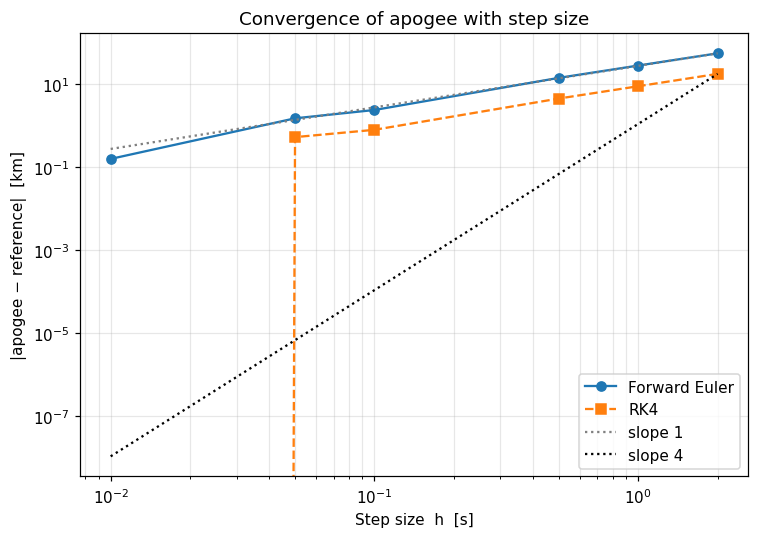

In [10]:
# Visualize convergence
dts, eul, rks = zip(*rows)
ref = rks[-1]                          # RK4 at h=0.01 ~ "true" apogee
err_e = np.abs(np.array(eul) - ref)
err_r = np.abs(np.array(rks) - ref)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dts, err_e, 'o-', label='Forward Euler')
ax.loglog(dts, err_r, 's--', label='RK4')
# Reference slope lines
h_ref = np.array([min(dts), max(dts)])
ax.loglog(h_ref, err_e[0]*(h_ref/dts[0])**1, ':', color='gray', label='slope 1')
ax.loglog(h_ref, err_r[0]*(h_ref/dts[0])**4, ':', color='black', label='slope 4')
ax.set_xlabel('Step size  h  [s]'); ax.set_ylabel('|apogee − reference|  [km]')
ax.set_title('Convergence of apogee with step size')
ax.grid(True, which='both', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 10. Discussion points

1. **Liftoff constraint.** Plugging numbers into $T/W$ before integrating tells
   us the rocket cannot accelerate upward at $t=0$. The pad-hold logic in `rhs`
   is what keeps the simulation physical with the assignment's parameters.

2. **Engine cutoff signature.** The velocity plot has a *kink* at $t = 300$ s
   (acceleration is discontinuous because thrust is). After cutoff, the rocket
   coasts under gravity + residual drag — exactly the ballistic regime that lets
   students compute apogee analytically as a sanity check.

3. **Why RK4 wins.** At $h = 2$ s, Forward Euler underestimates the apogee by
   $\sim 50$ km, while RK4 is already within $20$ km. The convergence plot above
   should land cleanly on slopes 1 and 4, demonstrating the theoretical
   orders of accuracy.

4. **Where Euler can fail.** Try `dt = 5.0` or larger — Euler will overshoot,
   oscillate, or in some parameterizations produce negative mass. RK4 remains
   well-behaved at much larger step sizes. This is the **numerical stability**
   point called out in the learning objective.

5. **Suggested extensions** (if time permits):
   - Switch to `solve_ivp` (`scipy.integrate`) and compare to a reference solver.
   - Replace the exponential atmosphere with the U.S. Standard Atmosphere 1976.
   - Add a gravity turn (pitch program) and lift to make this 2-D — a natural
     bridge from MAT423E into AE/MAE coursework.